In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# os → working with folders and operating system functions
# Path → managing files and file paths
# pandas → analyzing tables and structured data
# matplotlib → creating plots and visualizations

In [2]:
from pathlib import Path

dataset_path = Path("../data/raw")

print(dataset_path.exists())

# Path = tool for working with file and folder locations
# Path(...) → converts a file location into a Path object
# dataset_path = variable that stores the location of your dataset
# exists() = checks whether Python can find the folder
# We need this because the dataset consists of many images and folders, not a single CSV file

True


In [3]:
list(dataset_path.iterdir())
#iterdir is used to see what is in the file
#with list we get it as a python list 

[WindowsPath('../data/raw/.gitkeep'),
 WindowsPath('../data/raw/COVID'),
 WindowsPath('../data/raw/COVID.metadata.xlsx'),
 WindowsPath('../data/raw/Lung_Opacity'),
 WindowsPath('../data/raw/Lung_Opacity.metadata.xlsx'),
 WindowsPath('../data/raw/Normal'),
 WindowsPath('../data/raw/Normal.metadata.xlsx'),
 WindowsPath('../data/raw/README.md.txt'),
 WindowsPath('../data/raw/Viral Pneumonia'),
 WindowsPath('../data/raw/Viral Pneumonia.metadata.xlsx')]

In [4]:
classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

class_counts={}

for c in classes:
    folder = dataset_path / c / "images"      #navigating in the images file
    images = list(folder.glob("*.png"))  
    class_counts[c] = len(images)    

print(class_counts) 
    

# glob() → searches for files in a folder based on a specific pattern
# folder.glob("*.png") → finds all files that end with .png
# * → wildcard representing any characters (e.g. image1.png, covid123.png)
# list() → converts the result into a regular Python list
# len() → counts the number of elements in the list


{'COVID': 3616, 'Lung_Opacity': 6012, 'Normal': 10192, 'Viral Pneumonia': 1345}


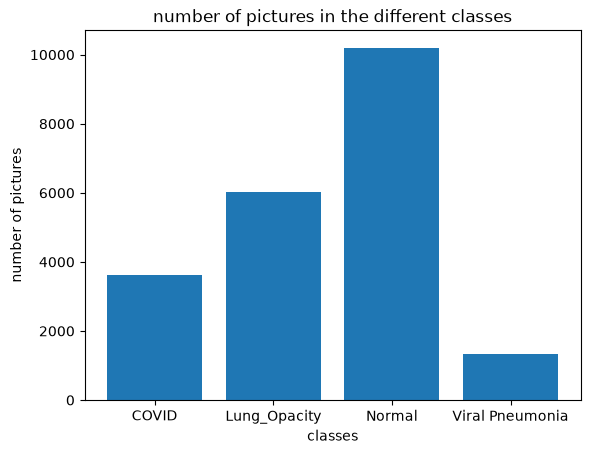

In [5]:
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("classes")
plt.ylabel("number of pictures")
plt.title("number of pictures in the different classes")
plt.show()

In [6]:
covid_metadata=pd.read_excel(dataset_path / "COVID.metadata.xlsx")
covid_metadata.head()
covid_metadata.info()
covid_metadata.isnull().sum()

lung_opacity_metadata=pd.read_excel(dataset_path / "Lung_Opacity.metadata.xlsx")
lung_opacity_metadata.head()
lung_opacity_metadata.info()
lung_opacity_metadata.isnull().sum()

normal_metadata=pd.read_excel(dataset_path / "Normal.metadata.xlsx")
normal_metadata.head()
normal_metadata.info()
normal_metadata.isnull().sum()

viral_pneumonia_metadata=pd.read_excel(dataset_path / "Viral Pneumonia.metadata.xlsx")
viral_pneumonia_metadata.head()
viral_pneumonia_metadata.info()
viral_pneumonia_metadata.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 3616 entries, 0 to 3615
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   FILE NAME  3616 non-null   str  
 1   FORMAT     3616 non-null   str  
 2   SIZE       3616 non-null   str  
 3   URL        3616 non-null   str  
dtypes: str(4)
memory usage: 113.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 6012 entries, 0 to 6011
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   FILE NAME  6012 non-null   str  
 1   FORMAT     6012 non-null   str  
 2   SIZE       6012 non-null   str  
 3   URL        6012 non-null   str  
dtypes: str(4)
memory usage: 188.0 KB
<class 'pandas.DataFrame'>
RangeIndex: 10192 entries, 0 to 10191
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   FILE NAME  10192 non-null  str  
 1   FORMAT     10192 non-null  str  
 2   SIZE       10192 non-nul

FILE NAME    0
FORMAT       0
SIZE         0
URL          0
dtype: int64

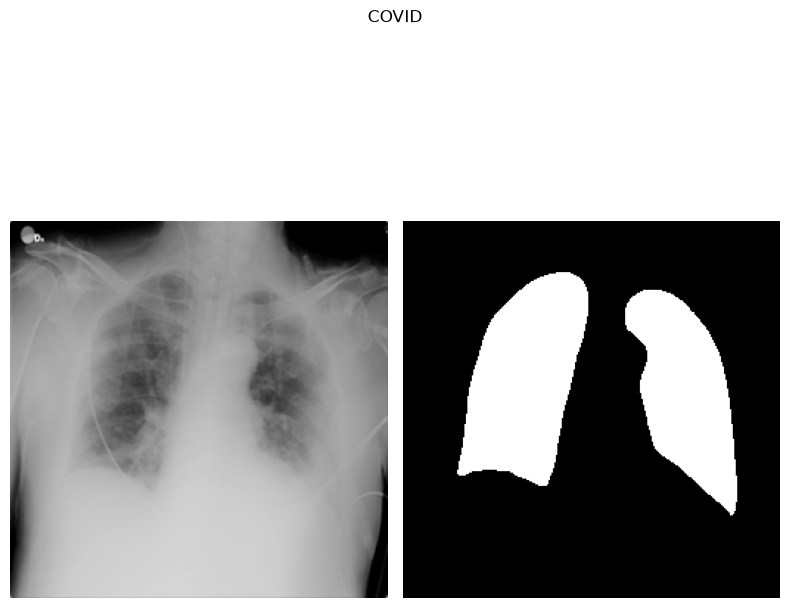

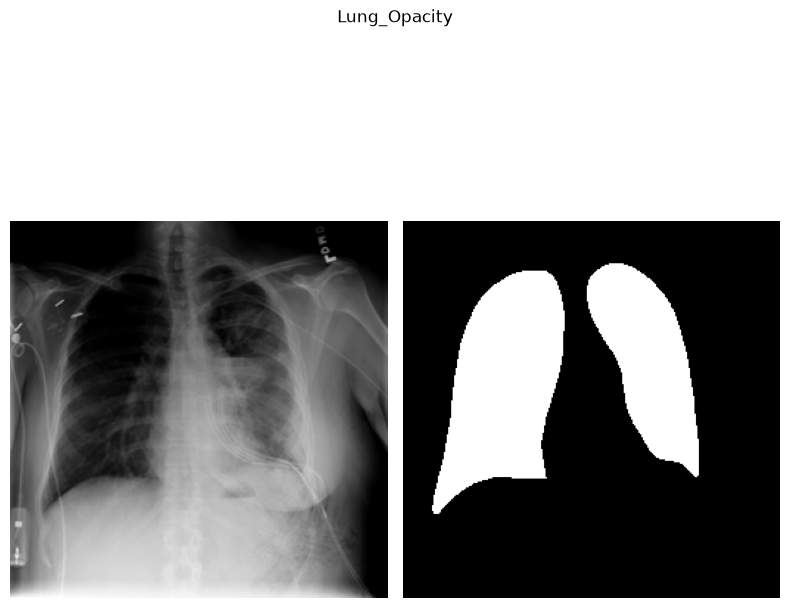

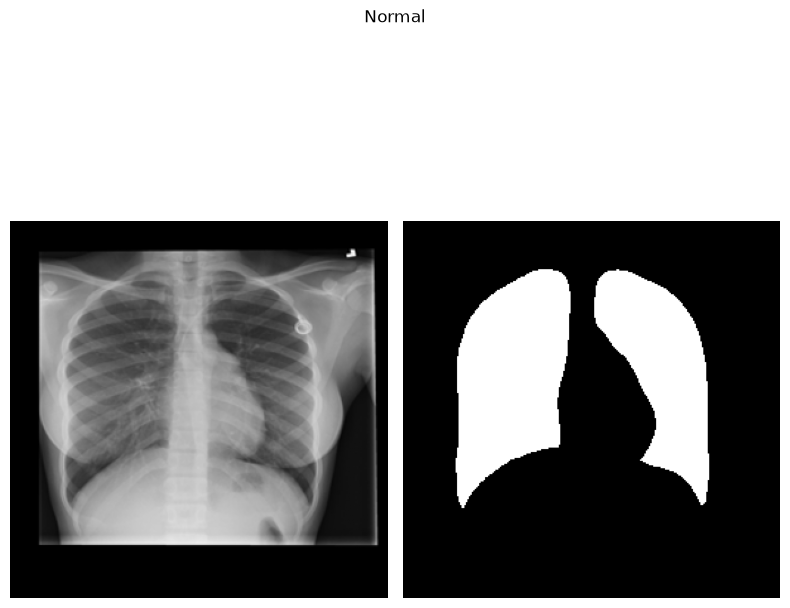

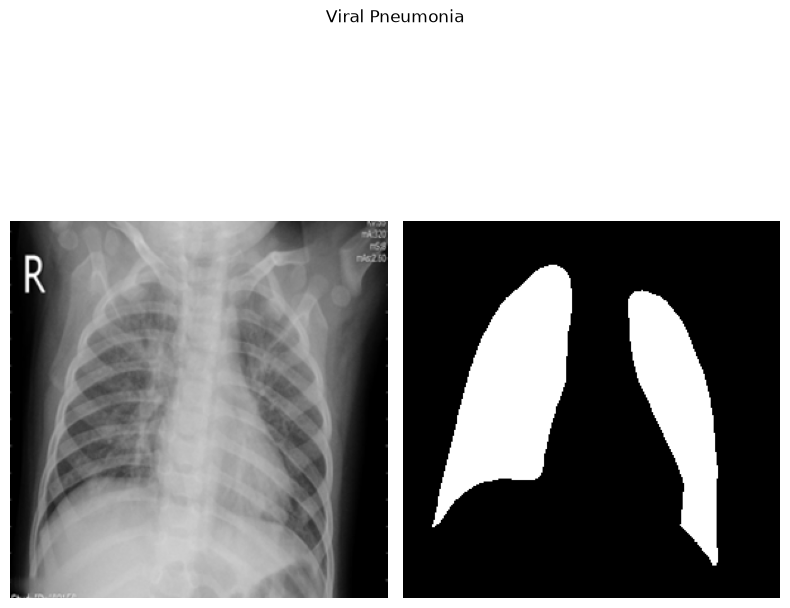

In [7]:
from PIL import Image          #Python Imaging Library (PIL): It provides functions to load, process and save images.

classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]



for c in classes:
    fig = plt.figure(figsize=(8,8)) #große Zeichenfläche erstellen
    plt.subplot(121)
    plt.suptitle(c)
    folder = dataset_path / c / "images"      #navigating in the images file
    images = list(folder.glob("*.png"))       #putting every image of the file in a list
    plt.imshow(Image.open(images[0]), cmap="gray")  #Image.open(): Opens an image file and loads it into Python as an image object. , plt.imshow()->showing the image in a matplot figure
    plt.axis("off") 
    plt.subplot(122) 
    folder = dataset_path / c / "masks" 
    masks=list(folder.glob("*.png"))
    plt.imshow(Image.open(masks[0]), cmap="gray")  #Image.open(): Opens an image file and loads it into Python as an image object. , plt.imshow()->showing the image in a matplot figure
    plt.axis("off") 
    plt.tight_layout() ## tight_layout(): Automatically adjusts spacing between subplots, labels and the figure borders to prevent overlapping.
    plt.show()
    
    #suptitle() gehört zur gesamten Figure.
    # Matplotlib reserviert automatisch Platz oben für diesen Titel.
    # Dadurch werden die Subplots nach unten geschoben → es entsteht die große weiße Fläche.
    # Das ist also kein Fehler, sondern normales Verhalten.




In [8]:
#checking if every image has the same size 

set_images=set()                     #set only saves unique values

classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

for c in classes:
    folder = dataset_path / c / "images"      #navigating in the images file
    images = list(folder.glob("*.png")) 
    for i in images:
        image_size=Image.open(i).size
        set_images.add(image_size)   
print(set_images)



{(299, 299)}


In [9]:
#checking if every mask have the same size

set_masks=set()                     #set only saves unique values

classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

for c in classes:
    folder = dataset_path / c / "masks"      #navigating in the images file
    images = list(folder.glob("*.png")) 
    for i in images:
        image_size=Image.open(i).size
        set_masks.add(image_size)   
print(set_masks)



{(256, 256)}


In [10]:
image_color=set()                     #set only saves unique values

classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

for c in classes:
    folder = dataset_path / c / "images"      #navigating in the images file
    images = list(folder.glob("*.png")) 
    for i in images:
        image_mode=Image.open(i).mode
        image_color.add(image_mode)   
print(image_color)


{'RGB', 'L'}


In [11]:
#counting the number of images in rgb and L mode

classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

mode_counts={}

for c in classes:
    folder = dataset_path / c / "images"      #navigating in the images file
    images = list(folder.glob("*.png"))  
    for i in images:
        image_mode=Image.open(i).mode
        if image_mode in mode_counts:
            mode_counts[image_mode] += 1
        else:
             mode_counts[image_mode]=1   

print(mode_counts) 

{'L': 21025, 'RGB': 140}


In [12]:
#checking if the masks all have the same color
masks_color=set()                     #set only saves unique values

classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

for c in classes:
    folder = dataset_path / c / "masks"      #navigating in the images file
    masks = list(folder.glob("*.png")) 
    for i in masks:
        masks_mode=Image.open(i).mode
        masks_color.add(masks_mode)   
print(masks_color)



{'RGB'}


In [13]:
mask_values=set() # Stores all unique pixel values found across the entire dataset.

classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

for c in classes:
    folder = dataset_path / c / "masks"
    masks = list(folder.glob("*.png"))

    for mask in masks:
        image = Image.open(mask)
        image_array=np.array(image)
        unique_rgbs=np.unique(image_array)    #Find all unique pixel values in the current mask.

        for v in unique_rgbs:
            mask_values.add(v)
# Add the pixel values of the current mask to the global set.
# The set automatically ignores duplicate values across all masks.

print(mask_values)

{np.uint8(0), np.uint8(255)}


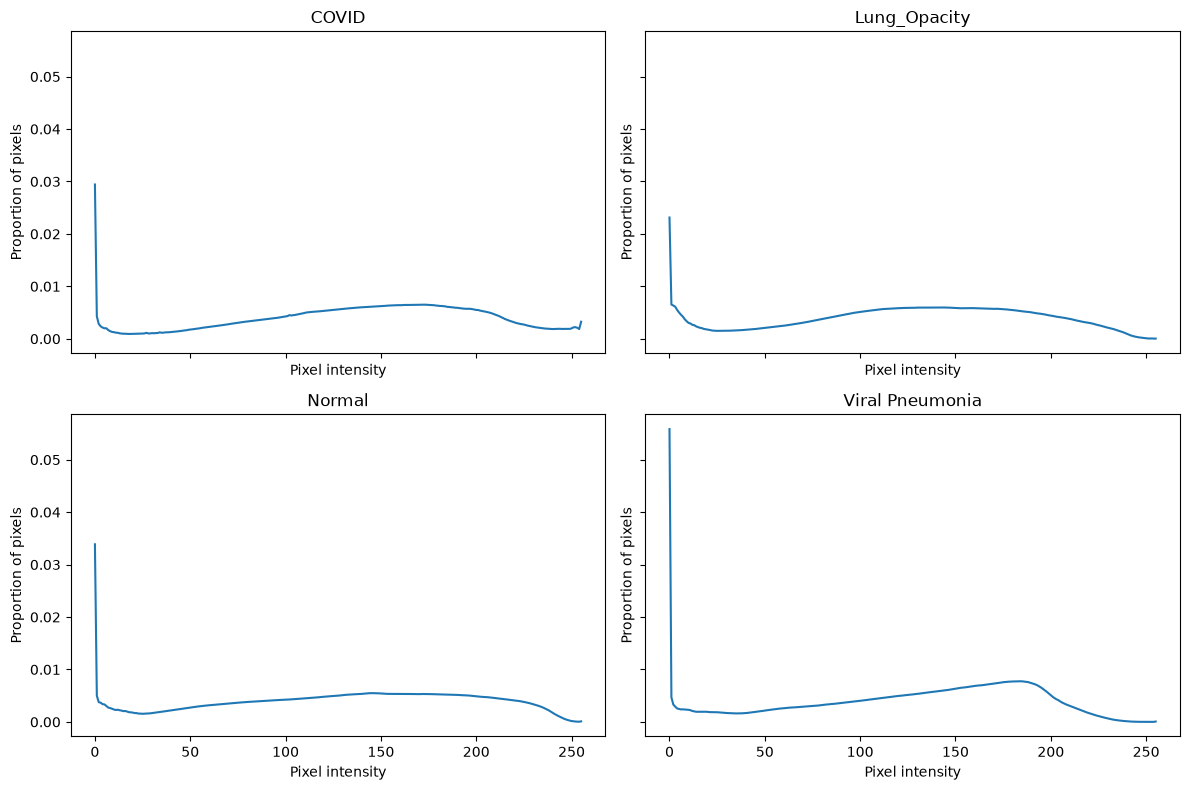

In [ ]:
classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for c, ax in zip(classes, axes.flat):
    counts = np.zeros(256, dtype=np.int64)
    folder = dataset_path / c / "images"

    for image_path in folder.glob("*.png"):
        with Image.open(image_path) as image:
            grayscale = np.asarray(image.convert("L"), dtype=np.uint8)
        counts += np.bincount(grayscale.ravel(), minlength=256)

    ax.plot(np.arange(256), counts / counts.sum())
    ax.set_title(c)
    ax.set_xlabel("Pixel intensity")
    ax.set_ylabel("Proportion of pixels")

plt.tight_layout()
plt.show()

In [15]:
#Distribution of RGB and L images 
classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]


for c in classes:
    mode_values=set()
    folder = dataset_path / c / "images"
    images = list(folder.glob("*.png"))
    for image in images:
        image = Image.open(image)
        image_mode=image.mode
        mode_values.add(image_mode)
    print(mode_values, c)
    if "RGB" in mode_values:
        print(f"{c} has RGB-values.")

{'L'} COVID
{'L'} Lung_Opacity
{'L'} Normal
{'RGB', 'L'} Viral Pneumonia
Viral Pneumonia has RGB-values.


COVID: mean=139.5, std=25.0
Lung_Opacity: mean=126.0, std=23.6
Normal: mean=129.4, std=22.4
Viral Pneumonia: mean=125.4, std=19.0


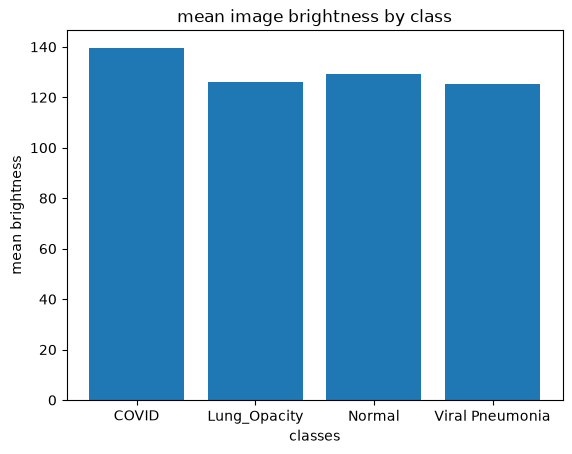

In [24]:
classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
class_brightness = {}
brightness_by_class = []

for c in classes:
    folder = dataset_path / c / "images"
    brightness_values = []

    for image_path in folder.glob("*.png"):
        with Image.open(image_path) as image:
            grayscale = np.asarray(image.convert("L"), dtype=np.uint8)
        brightness_values.append(grayscale.mean())

    class_brightness[c] = np.mean(brightness_values)
    brightness_by_class.append(brightness_values)
    print(f"{c}: mean={class_brightness[c]:.1f}, std={np.std(brightness_values):.1f}")

plt.bar(class_brightness.keys(), class_brightness.values())
plt.xlabel("classes")
plt.ylabel("mean brightness")
plt.title("mean image brightness by class")
plt.show()

plt.boxplot(brightness_by_class, tick_labels=classes)
plt.ylabel("brightness")
plt.title("brightness by class")
plt.show()

COVID: mean=54.6, std=14.8
Lung_Opacity: mean=57.4, std=9.8
Normal: mean=61.6, std=9.6
Viral Pneumonia: mean=58.7, std=10.8


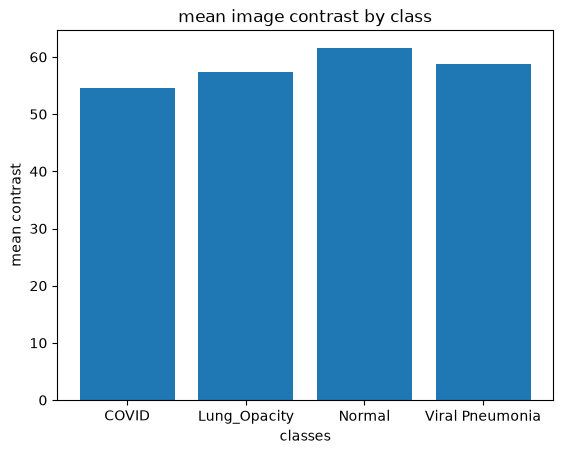

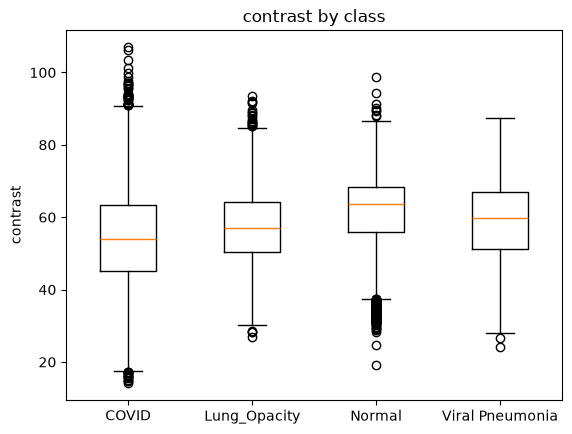

In [26]:
classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
class_contrast = {}
contrast_by_class = []

for c in classes:
    folder = dataset_path / c / "images"
    contrast_values = []

    for image_path in folder.glob("*.png"):
        with Image.open(image_path) as image:
            grayscale = np.asarray(image.convert("L"), dtype=np.uint8)
        contrast_values.append(grayscale.std())

    class_contrast[c] = np.mean(contrast_values)
    contrast_by_class.append(contrast_values)
    print(f"{c}: mean={class_contrast[c]:.1f}, std={np.std(contrast_values):.1f}")

plt.bar(class_contrast.keys(), class_contrast.values())
plt.xlabel("classes")
plt.ylabel("mean contrast")
plt.title("mean image contrast by class")
plt.show()

plt.boxplot(contrast_by_class, tick_labels=classes)
plt.ylabel("contrast")
plt.title("contrast by class")
plt.show()